# Chapter 9: Machine Learning Intro 1

In [1]:
import matplotlib.image as img
import matplotlib.pyplot as plt

import copy
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from os import listdir
from sklearn.model_selection import train_test_split
import seaborn as sns; sns.set()
from sklearn import metrics

## 9.1 Introduction

By now we have seen how to load in data, analyze it, and modify it to fit our needs. Great! But what exactly are we going to do with this? The most common goal is to create machine learning models that make interesting predictions based on our data. By doing so, we can solve real-world problems and hopefully make our bosses happy 📊

But first, let's take a step back. What exactly is machine learning? Well, in a world dominated by AI chatbots like ChatGPT, Grok, and DeepSeek, it's easy to label everything as "AI." However, machine learning is more specific; it's a subset of AI where the focus lies on gathering data, cleaning and preparing it (which you should be able to do by now), feeding it to an algorithm, and tweaking it until you're happy with the results. In other words, it's the little brother of ChatGPT that you constantly have to babysit, but it's a lot of fun to work with!

While there are many different machine learning models out there, each with their own nuances, we won't explore their specifics here; that's for next year in your Machine Learning and Data Science Fundamentals classes. Instead, we'll focus on how to use the data we've prepared to train a machine learning model, how to improve it, and how to evaluate the results. Think of this as your first taste of what's to come! 🎯

## 9.2 The Flower Dataset

Today we will be working with the flower dataset. This is a dataset containing, you guessed it, flowers! Each flower is noted with some measurements of the leaves, as well as the name of the flower. Load in the data and have a look.

In [2]:
iris = pd.read_csv('iris_data.csv')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Question 1: based off this data, what kind of information might we aim to predict or discover using Machine Learning models?

To start, each column might be an interesting variable to try and predict when a new flower comes in. The obvious first choice here is the "species" column, as it shows exactly what kind of flower we have. Trying to predict this based on the measurements of the leaves is a typical example of **classification**. The remaining columns can also be interesting to predict. Say we have found half a leaf of a setoa, based on the width of the leaf and the type of flower, we might be able to predict exactly how long the leaf was. This is a typical example of **regression**.

There are also other interesting things we might try to discover. Maybe we are able to discover some patterns in the data that we have not found before. By throwing the data in a model and asking it to group similar flowers together, we might find some groups of sub species. Even though we will not get a name for this, by knowing they are very similar we can investigate it further. This is a clear example of **clustering**.

### Question 2: Let's have a first look at the data. How can we gain insights from our dataset? What can we learn from this?

In [3]:
iris.shape

(150, 5)

We can see that we have 150 flower records, and 5 columns containing data.

In [4]:
iris.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

All of our columns are floats, except for the 'species' column, which is an object. This is to be expected, as that column contains the name of our flower, also known as the "label" in machine learning.

We can also note that since the other columns are floats (and we know they contain measurements), there likely won't be any missing values. If there were missing values, the column data types would show up differently.

In [5]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


We can confirm that there are no missing values, as the count is 150 across all columns. There are also no strange (zero, negative or abnormally high) values as the minimum or maximum values.

## 9.3 Our first ML model

Now it's time to dive into machine learning and create our first model! We won't explore the specifics of which model to choose or how it works internally; you'll do plenty of that next year. For now, just follow along (but feel free to do your own research if you're curious!).

Creating a model in python is actually really easy, all it takes is just a single line of code:

In [6]:
ML_model = RandomForestClassifier()
ML_model

RandomForestClassifier()

While we have created our model, it has not yet fitted the data which means it hasn't learned anything yet. This is logical, as we haven't given it any data yet. To do so, we need two things:

1) X, which is the raw dataset which it can use to learn the appropriate patterns
2) Y, the outcome vector (the labels it should try to learn)

### Question 3: It is extremely important to make sure that the outcome vector Y is not in X. Can you think why this is?

if we include Y in our X, the model will use Y to predict Y. Of course, this means it will not learn anything from the data and just repeat what is in the Y column. It's the same as trying to guess the age of a person, when they are wearing a hat with their age on it. You don't have to look at the person itself, you just read what's on the hat. This is called a **data leak** for obvious reasons.

### Question 4: Prepare the X and Y variables. The X subset should contain 'sepal_length', 'sepal_width', 'petal_length' and 'petal_width' while the Y variable should only contain 'species'.

In [7]:
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
Y = iris['species']

Once you have prepared the data, train your model.

In [8]:
ML_model.fit(X, Y)
ML_model

RandomForestClassifier()

Nothing seems to have changed on screen, but we did fit the model to the data, so now it should work. Let's test it by creating a fake flower and seeing what prediction it makes.

In [9]:
fake_flower = pd.DataFrame({'sepal_length': 5, 
                               'sepal_width' :3,
                               'petal_length' : 1,
                               'petal_width': 0.5}, index = [0])
                           
fake_flower                          

,sepal_length,sepal_width,petal_length,petal_width
0,5,3,1,0.5


In [10]:
ML_model.predict(fake_flower)

array(['setosa'], dtype=object)

Great! The model is working. It gave us a prediction for our fake flower. Now let's check if the model has actually learned correctly by testing it on the original data and comparing its predictions with the true labels.

In [11]:
y_pred = ML_model.predict(X)

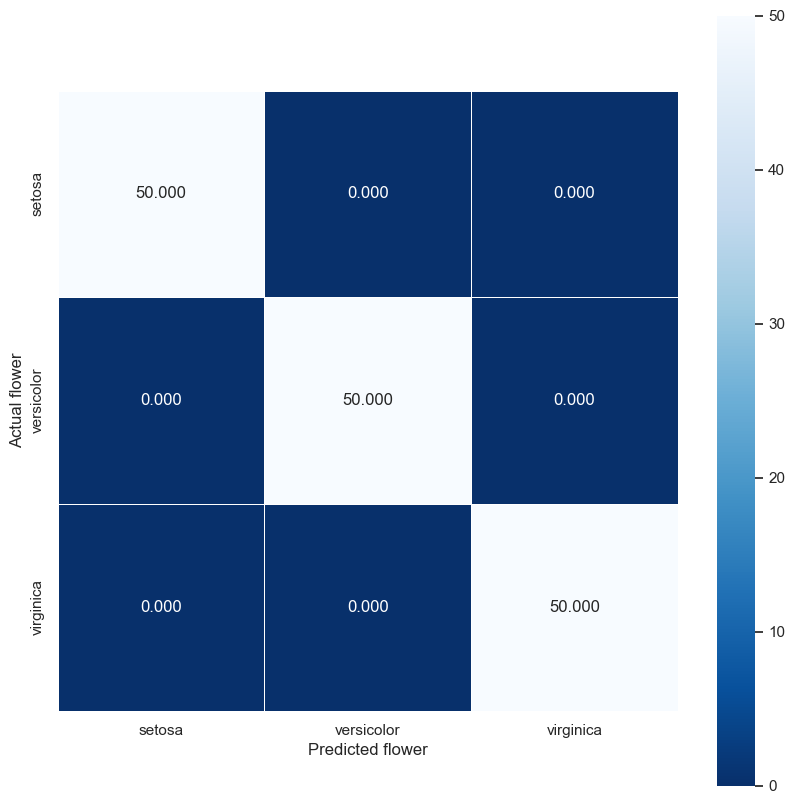

In [12]:
labels = ['setosa', 'versicolor', 'virginica']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(Y, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual flower');
plt.xlabel('Predicted flower');

### Question 5: How can we interpret the matrix above? Do you notice anything suspicious? Can you explain it?

Wow, the model has perfectly learned the difference between all flowers. Perfect accuracy! 🎉

But wait... some of you with good instincts are probably thinking something seems off. How can it make zero mistakes? Surely the problem isn't that easy?

You're right! We're making a critical mistake: we're testing the model on the same data we used to train it. It's like taking a test with the exact same questions from your practice exercises. Of course you'll know the answers, but that doesn't mean you've learned the entire subject.

We can fix this using a **train-test split**. We'll divide our data into two parts: one for training the model (the training set) and one for testing it afterwards (the test set). 

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25) 

In [14]:
X_train.shape

(112, 4)

In [15]:
X_test.shape

(38, 4)

### Question 6: Based on the values above, what does the test_size parameter do?

Our X_train dataset contains 112 records (about 75% of the original), while X_test contains 38 records (about 25%). This shows what the `test_size` parameter does; it controls how much data we reserve for testing. Usually, a value between 20% and 30% is chosen.

As we can see the train_test_split function has given us a number of things:

1) training data (X_train)
2) training outcome to predict (y_train)
3) test data (X_test)
4) test outcome to predict (y_test)

Let's fit the model again on the training data. To do so, let's create a new empty model first.

In [16]:
ML_model = RandomForestClassifier()
ML_model

ML_model.fit(X_train, y_train)

RandomForestClassifier()

Now let's evaluate it. Let's check the train data first. We suspect that this will be good since it has used this data for learning.

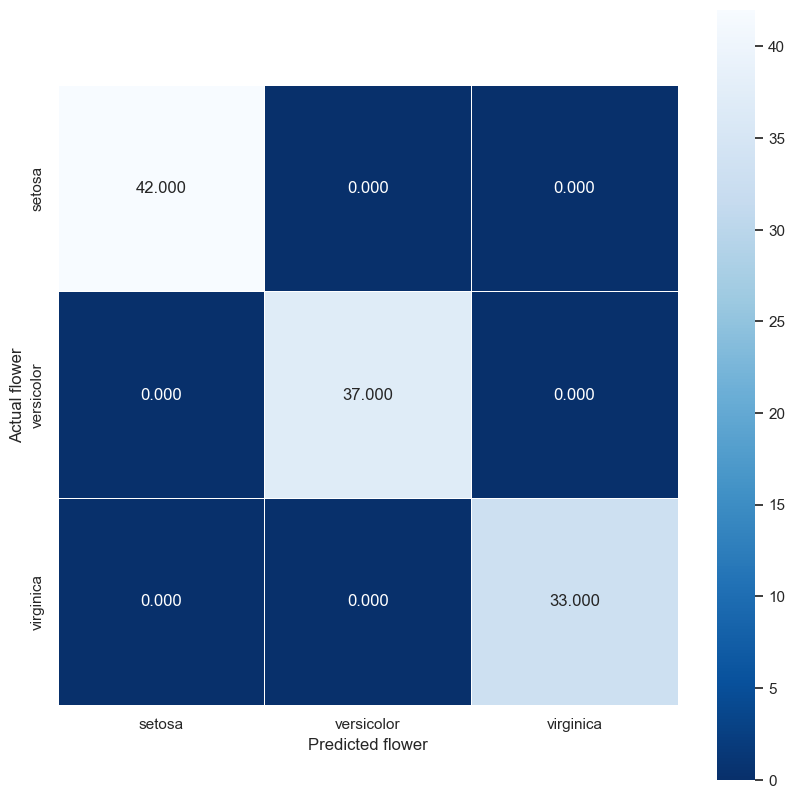

In [17]:
y_pred = ML_model.predict(X_train)

labels = ['setosa', 'versicolor', 'virginica']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(y_train, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual flower');
plt.xlabel('Predicted flower');

As expected, no faults. But now for the unseen test data:

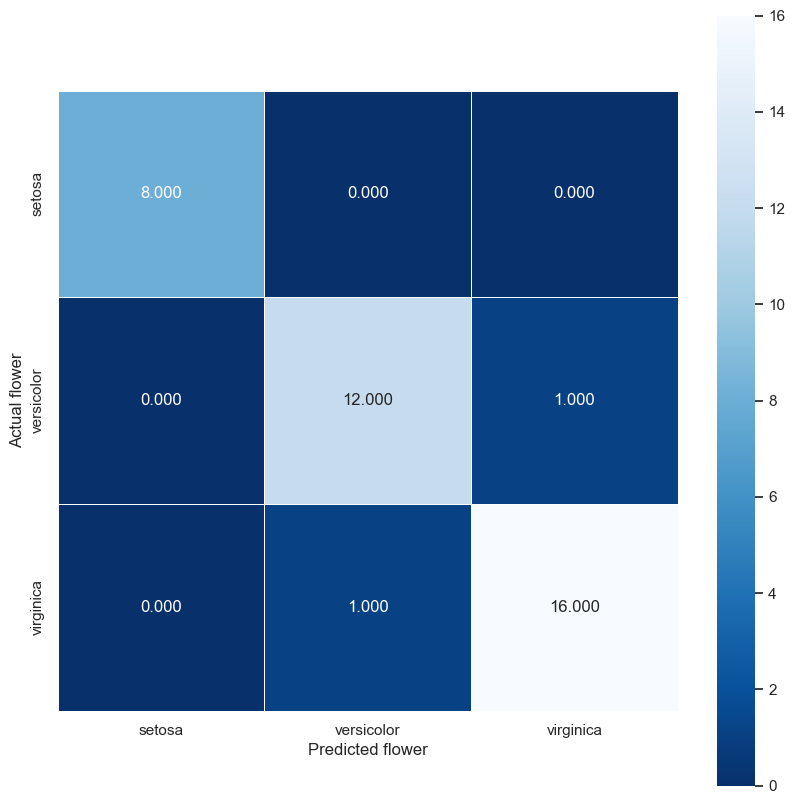

In [18]:
y_pred = ML_model.predict(X_test)

labels = ['setosa', 'versicolor', 'virginica']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual flower');
plt.xlabel('Predicted flower');

### Question 7: What has changed? What does this mean?

The results on unseen data are not perfect; 2 versicolor flowers are predicted as 'virginica.' However, the results are still very good! This tells us the model has genuinely learned the problem, and it seems this particular classification task isn't too difficult for this algorithm.